# SWE-chat dataset tour

Explore the dataset through statistics and visualizations from [SWE-chat: Coding Agent Interactions From Real Users in the Wild](https://arxiv.org/abs/2604.20779) (COLM 2026). Embedded outputs use the v2 snapshot with data through September 4, 2026.

Before downloading, request access on the [Hugging Face dataset page](https://huggingface.co/datasets/SALT-NLP/SWE-chat) and run `hf auth login`. Alternatively, set `SWECHAT_LOCAL_DIR` to a local directory containing the parquet files. Allow about 4 GB of working memory plus headroom and roughly 7 GB of disk space.

Behavior analyses exclude `dayhaysoos/nimbus` and sessions without conversation rows (17,262 sessions in v2).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import swechat as sc

sc.use_paper_style()

## Dataset statistics

Overall size of the release (Section 2.1).

In [2]:
turns = sc.read_table("conversations", ["turn_type"], exclude_repos=False)

pd.Series({
    "Repositories":     len(sc.read_table("repositories", ["repo_id"], exclude_repos=False)),
    "Sessions":         len(sc.session_ids_with_turns()),
    "Checkpoints":      len(sc.read_table("checkpoints", ["checkpoint_pk"], exclude_repos=False)),
    "User prompts":     int((turns["turn_type"] == "user_prompt").sum()),
    "Agent tool calls": int((turns["turn_type"] == "tool_use").sum()),
    "Logged events":    len(turns),
}).map("{:,}".format).to_frame("count")

,count
Repositories,707
Sessions,"17,819"
Checkpoints,"54,918"
User prompts,"229,909"
Agent tool calls,"2,028,951"
Logged events,"11,607,572"


## Coding modes

The share of committed code written by the agent is strongly bimodal (Figure 5).

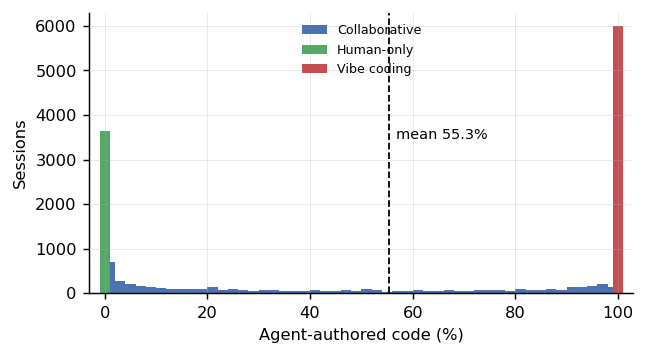

In [3]:
sessions = sc.load_sessions(["session_success", "user_persona", "created_at"])
pct = pd.to_numeric(sessions["agent_percentage"], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(5.4, 2.8))
middle = pct[(pct > 0) & (pct < sc.VIBE_THRESHOLD)]
ax.hist(middle, bins=np.linspace(0, 100, 51), color=sc.MODE_COLORS["Collaborative"],
        label="Collaborative")
ax.bar(0, (pct == 0).sum(), width=2, color=sc.MODE_COLORS["Human-only"], label="Human-only")
ax.bar(100, (pct >= sc.VIBE_THRESHOLD).sum(), width=2,
       color=sc.MODE_COLORS["Vibe coding"], label="Vibe coding")
ax.axvline(pct.mean(), color="k", ls="--", lw=1)
ax.annotate(f"mean {pct.mean():.1f}%", (pct.mean(), ax.get_ylim()[1] * 0.55),
            xytext=(4, 0), textcoords="offset points", fontsize=8)
ax.set_xlabel("Agent-authored code (%)")
ax.set_ylabel("Sessions")
ax.set_xlim(-3, 103)
ax.legend(fontsize=7, frameon=False, loc="upper center")
plt.show()

Grouping sessions into three coding modes (Figure 19e).

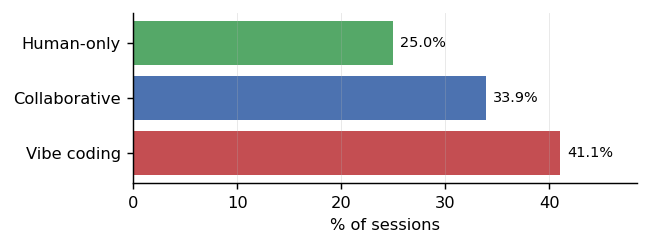

In [4]:
shares = (sessions["coding_mode"].value_counts(normalize=True) * 100)[sc.CODING_MODES]

fig, ax = plt.subplots(figsize=(5.0, 1.7))
ax.barh(shares.index, shares.values, color=[sc.MODE_COLORS[m] for m in shares.index])
for mode, value in shares.items():
    ax.annotate(f"{value:.1f}%", (value, mode), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_xlabel("% of sessions")
ax.set_xlim(0, shares.max() * 1.18)
ax.invert_yaxis()
ax.xaxis.grid(True); ax.yaxis.grid(False)
plt.show()

## Coding modes over time

The 14-day rolling vibe-coding share rose from a February low of 18.3% to 52.6% on September 4 (Figure 25).

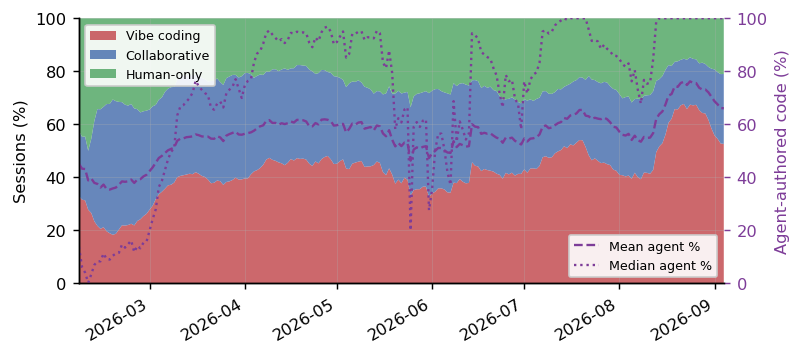

In [5]:
day = pd.to_datetime(sessions["created_at"], utc=True, errors="coerce").dt.floor("D")
dated = sessions.assign(day=day).dropna(subset=["day"]).sort_values("day")

counts = pd.crosstab(dated["day"], dated["coding_mode"]).reindex(columns=sc.CODING_MODES,
                                                                fill_value=0)
start, end = counts.index.min(), counts.index.max()
counts = counts.reindex(pd.date_range(start, end, freq="D")).fillna(0)
window = counts.rolling("14D").sum()
share = (window.div(window.sum(axis=1), axis=0) * 100).loc[start + pd.Timedelta(days=14):]

agent_pct = pd.to_numeric(dated.set_index("day")["agent_percentage"], errors="coerce")
mean_pct = agent_pct.rolling("14D").mean().resample("D").last().loc[share.index]
median_pct = agent_pct.rolling("14D").median().resample("D").last().loc[share.index]

fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.stackplot(share.index, *[share[m] for m in ["Vibe coding", "Collaborative", "Human-only"]],
             labels=["Vibe coding", "Collaborative", "Human-only"],
             colors=[sc.MODE_COLORS[m] for m in ["Vibe coding", "Collaborative", "Human-only"]],
             alpha=0.85)
ax.set_ylabel("Sessions (%)")
ax.set_ylim(0, 100)
ax.set_xlim(share.index.min(), share.index.max())
ax.legend(loc="upper left", fontsize=7, frameon=True, framealpha=0.9)

right = ax.twinx()
right.plot(mean_pct.index, mean_pct.values, color="#7D3C98", ls="--", lw=1.3,
           label="Mean agent %")
right.plot(median_pct.index, median_pct.values, color="#7D3C98", ls=":", lw=1.3,
           label="Median agent %")
right.set_ylabel("Agent-authored code (%)", color="#7D3C98")
right.set_ylim(0, 100)
right.tick_params(axis="y", colors="#7D3C98")
right.grid(False)
right.legend(loc="lower right", fontsize=7, frameon=True, framealpha=0.9)
fig.autofmt_xdate()
plt.show()

## Session success

Most sessions are rated as largely successful (Figure 6).

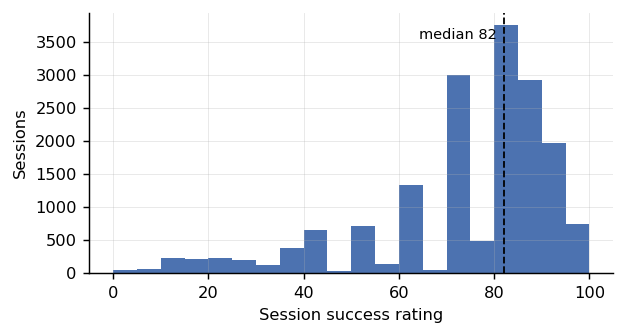

87.5% of sessions score 50 or above


In [6]:
success = pd.to_numeric(sessions["session_success"], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(5.2, 2.6))
ax.hist(success, bins=np.linspace(0, 100, 21), color="#4c72b0")
ax.axvline(success.median(), color="k", ls="--", lw=1)
ax.annotate(f"median {success.median():.0f}", (success.median(), ax.get_ylim()[1] * 0.9),
            xytext=(-4, 0), textcoords="offset points", ha="right", fontsize=8)
ax.set_xlabel("Session success rating")
ax.set_ylabel("Sessions")
plt.show()

print(f"{(success >= 50).mean() * 100:.1f}% of sessions score 50 or above")

## User personas

Expert nitpicking is the most common interaction style (Figure 24).

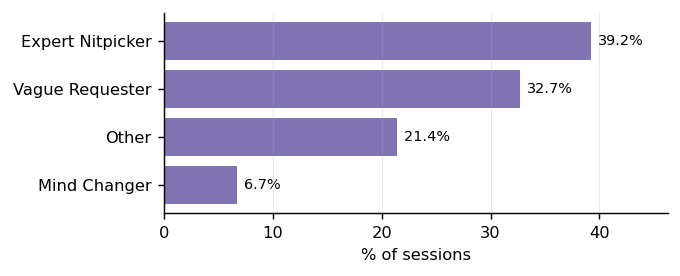

In [7]:
personas = (sessions["user_persona"].value_counts(normalize=True) * 100).sort_values()

fig, ax = plt.subplots(figsize=(5.0, 2.0))
ax.barh(personas.index, personas.values, color="#8172b3")
for name, value in personas.items():
    ax.annotate(f"{value:.1f}%", (value, name), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_xlabel("% of sessions")
ax.set_xlim(0, personas.max() * 1.18)
ax.xaxis.grid(True); ax.yaxis.grid(False)
plt.show()

## Prompt intents

Understanding existing code is the most common specific intent (Figure 19a).

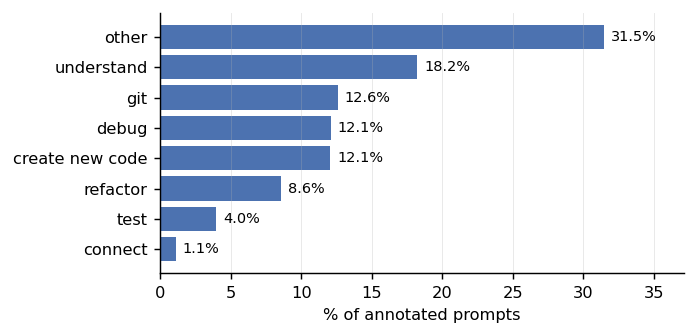

In [8]:
prompts = sc.load_conversations(["turn_type", "prompt_intent"])
intents = prompts.loc[prompts["turn_type"] == "user_prompt", "prompt_intent"].dropna()
intent_share = (intents.value_counts(normalize=True) * 100).sort_values()
del prompts

fig, ax = plt.subplots(figsize=(5.2, 2.6))
ax.barh(intent_share.index, intent_share.values, color="#4c72b0")
for name, value in intent_share.items():
    ax.annotate(f"{value:.1f}%", (value, name), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_xlabel("% of annotated prompts")
ax.set_xlim(0, intent_share.max() * 1.18)
ax.xaxis.grid(True); ax.yaxis.grid(False)
plt.show()

## Tool calls

Shell commands account for the largest share of agent tool calls (Figure 19b, Table 5).

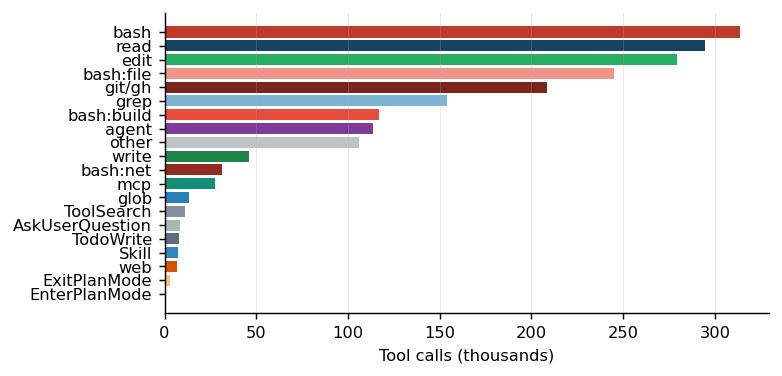

,count,%
tool_category,,
read,"294,394",14.7
grep,"154,160",7.7
glob,"13,535",0.7
bash:file,"245,291",12.3
bash:build,"117,014",5.9
bash:net,"31,556",1.6
bash,"313,837",15.7
git/gh,"208,746",10.5
write,"46,106",2.3


In [9]:
calls = sc.load_tool_calls()
counts = calls["tool_category"].value_counts()
del calls

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ordered = counts.sort_values()
ax.barh(ordered.index, ordered.values / 1000,
        color=[sc.TOOL_COLORS.get(t, "#BDC3C7") for t in ordered.index])
ax.set_xlabel("Tool calls (thousands)")
ax.xaxis.grid(True); ax.yaxis.grid(False)
plt.show()

table = counts.reindex(sc.TOOL_ORDER).to_frame("count")
table["%"] = (table["count"] / table["count"].sum() * 100).round(1)
table["count"] = table["count"].map("{:,}".format)
table